<a href="https://colab.research.google.com/github/KavindaKGD/Franklin-Models/blob/ProtoNet/ProtoNet%2BConv_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF:", tf.__version__)


TF: 2.19.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
DATA_ROOT = "/content/drive/MyDrive/fp_dataset"  # <-- change
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR   = os.path.join(DATA_ROOT, "val")

CLASS_NAMES = ["fp", "healthy", "barnacles"]  # must match folder names exactly
N_WAY = 3

for c in CLASS_NAMES:
    print(c, "train:", len(os.listdir(os.path.join(TRAIN_DIR, c))),
             "val:", len(os.listdir(os.path.join(VAL_DIR, c))))


fp train: 4 val: 2
healthy train: 4 val: 2
barnacles train: 4 val: 2


In [ ]:
def list_images_by_class(base_dir, class_names):
    by_class = {}
    for idx, cname in enumerate(class_names):
        cdir = os.path.join(base_dir, cname)
        files = []
        for f in os.listdir(cdir):
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
                files.append(os.path.join(cdir, f))
        by_class[idx] = sorted(files)
    return by_class

train_by_class = list_images_by_class(TRAIN_DIR, CLASS_NAMES)
val_by_class   = list_images_by_class(VAL_DIR, CLASS_NAMES)

print("Train by class:", {k: len(v) for k, v in train_by_class.items()})
print("Val by class:", {k: len(v) for k, v in val_by_class.items()})


Train by class: {0: 4, 1: 4, 2: 4}
Val by class: {0: 2, 1: 2, 2: 2}


In [ ]:
IMG_SIZE = 224

augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
])

def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img


In [ ]:
def build_conv4_encoder(embedding_dim=128):
    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = inp
    for filters in [32, 64, 128, 256]:
        x = tf.keras.layers.Conv2D(filters, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.MaxPool2D()(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(embedding_dim)(x)

    # Keras-safe L2 normalization
    out = tf.keras.layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=-1))(x)
    return tf.keras.Model(inp, out, name="Conv4_Encoder")

encoder = build_conv4_encoder(embedding_dim=128)
encoder.summary()


Model: "Conv4_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,232 (1.61 MB)

 Trainable params: 422,272 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
K_SHOT = 1   # support per class (train)
Q_QUERY = 1  # query per class (train)
# Note: train has 4 images/class, so K+Q must be <=4

def sample_episode(by_class, k_shot, q_query, training=True):
    # fixed 3-way = all classes
    support_imgs, support_labels = [], []
    query_imgs, query_labels = [], []

    for c in range(N_WAY):
        files = by_class[c]
        chosen = random.sample(files, k_shot + q_query)
        support_files = chosen[:k_shot]
        query_files   = chosen[k_shot:]

        for p in support_files:
            img = load_image(p)
            if training:
                img = augment(img, training=True)
            support_imgs.append(img)
            support_labels.append(c)

        for p in query_files:
            img = load_image(p)
            if training:
                img = augment(img, training=True)
            query_imgs.append(img)
            query_labels.append(c)

    support_imgs = tf.stack(support_imgs)  # (N*K, H, W, 3)
    query_imgs   = tf.stack(query_imgs)    # (N*Q, H, W, 3)
    support_labels = tf.convert_to_tensor(support_labels, dtype=tf.int32)
    query_labels   = tf.convert_to_tensor(query_labels, dtype=tf.int32)

    return support_imgs, support_labels, query_imgs, query_labels


In [ ]:
def prototypical_logits(encoder, support_imgs, support_labels, query_imgs):
    # embeddings
    z_support = encoder(support_imgs, training=True)  # (N*K, D)
    z_query   = encoder(query_imgs, training=True)    # (N*Q, D)

    # prototypes: mean embedding per class
    prototypes = []
    for c in range(N_WAY):
        mask = tf.where(tf.equal(support_labels, c))[:, 0]
        cls_emb = tf.gather(z_support, mask)
        proto = tf.reduce_mean(cls_emb, axis=0)
        prototypes.append(proto)
    prototypes = tf.stack(prototypes)  # (N, D)

    # squared euclidean distance: (num_query, N)
    # dist(q, p) = sum((q - p)^2)
    q = tf.expand_dims(z_query, axis=1)      # (num_query, 1, D)
    p = tf.expand_dims(prototypes, axis=0)   # (1, N, D)
    dists = tf.reduce_sum(tf.square(q - p), axis=-1)  # (num_query, N)

    # logits = -distance (closer -> higher logit)
    logits = -dists
    return logits


In [ ]:
optimizer = tf.keras.optimizers.Adam(1e-4)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

EPOCHS = 80
EPISODES_PER_EPOCH = 60  # increase if you want (more is better)

train_loss_hist, train_acc_hist = [], []
val_loss_hist, val_acc_hist = [], []

@tf.function
def train_step(support_imgs, support_labels, query_imgs, query_labels):
    with tf.GradientTape() as tape:
        logits = prototypical_logits(encoder, support_imgs, support_labels, query_imgs)
        loss = loss_fn(query_labels, logits)

    grads = tape.gradient(loss, encoder.trainable_variables)
    optimizer.apply_gradients(zip(grads, encoder.trainable_variables))

    preds = tf.argmax(logits, axis=1, output_type=tf.int32)
    acc = tf.reduce_mean(tf.cast(tf.equal(preds, query_labels), tf.float32))
    return loss, acc

def eval_episodes(by_class, episodes=30):
    losses, accs = [], []
    for _ in range(episodes):
        s_img, s_lab, q_img, q_lab = sample_episode(by_class, k_shot=1, q_query=1, training=False)
        logits = prototypical_logits(encoder, s_img, s_lab, q_img)
        loss = loss_fn(q_lab, logits).numpy()
        preds = tf.argmax(logits, axis=1, output_type=tf.int32)
        acc = tf.reduce_mean(tf.cast(tf.equal(preds, q_lab), tf.float32)).numpy()
        losses.append(loss); accs.append(acc)
    return float(np.mean(losses)), float(np.mean(accs))

for epoch in range(1, EPOCHS + 1):
    losses, accs = [], []

    for _ in range(EPISODES_PER_EPOCH):
        s_img, s_lab, q_img, q_lab = sample_episode(train_by_class, K_SHOT, Q_QUERY, training=True)
        loss, acc = train_step(s_img, s_lab, q_img, q_lab)
        losses.append(float(loss.numpy()))
        accs.append(float(acc.numpy()))

    tr_loss, tr_acc = np.mean(losses), np.mean(accs)
    va_loss, va_acc = eval_episodes(val_by_class, episodes=30)

    train_loss_hist.append(tr_loss); train_acc_hist.append(tr_acc)
    val_loss_hist.append(va_loss);   val_acc_hist.append(va_acc)

    print(f"Epoch {epoch:03d} | train loss {tr_loss:.4f} acc {tr_acc:.3f} | val loss {va_loss:.4f} acc {va_acc:.3f}")


Epoch 001 | train loss 0.6084 acc 0.850 | val loss 1.3156 acc 0.444
Epoch 002 | train loss 0.1619 acc 1.000 | val loss 1.7951 acc 0.200
Epoch 003 | train loss 0.1172 acc 1.000 | val loss 1.8354 acc 0.211
Epoch 004 | train loss 0.1150 acc 1.000 | val loss 1.8775 acc 0.089
Epoch 005 | train loss 0.1096 acc 1.000 | val loss 1.8985 acc 0.144
Epoch 006 | train loss 0.1051 acc 1.000 | val loss 1.7819 acc 0.244
Epoch 007 | train loss 0.1028 acc 1.000 | val loss 1.6865 acc 0.322
Epoch 008 | train loss 0.1029 acc 1.000 | val loss 1.7072 acc 0.300
Epoch 009 | train loss 0.1028 acc 1.000 | val loss 1.6624 acc 0.311
Epoch 010 | train loss 0.1016 acc 1.000 | val loss 1.6131 acc 0.367
Epoch 011 | train loss 0.1020 acc 1.000 | val loss 1.6035 acc 0.333
Epoch 012 | train loss 0.0997 acc 1.000 | val loss 1.6751 acc 0.344
Epoch 013 | train loss 0.0996 acc 1.000 | val loss 1.5451 acc 0.322
Epoch 014 | train loss 0.0997 acc 1.000 | val loss 1.5206 acc 0.267
Epoch 015 | train loss 0.1007 acc 1.000 | val lo

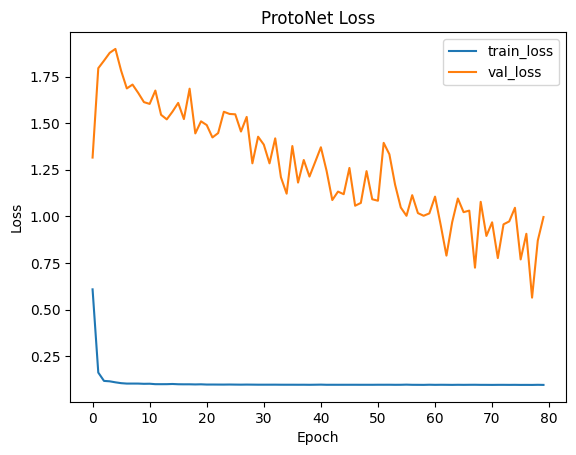

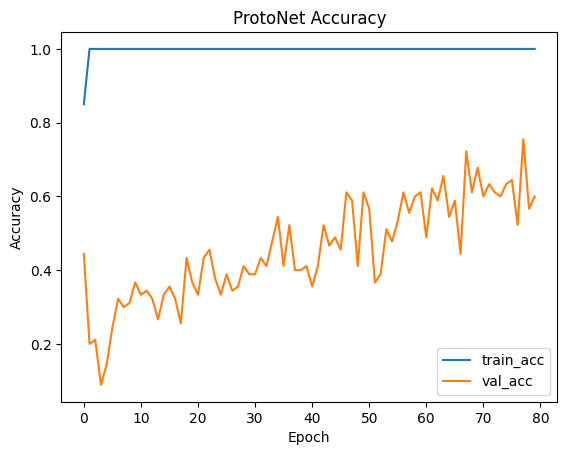

In [ ]:
plt.figure()
plt.plot(train_loss_hist, label="train_loss")
plt.plot(val_loss_hist, label="val_loss")
plt.title("ProtoNet Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(train_acc_hist, label="train_acc")
plt.plot(val_acc_hist, label="val_acc")
plt.title("ProtoNet Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/sea_turtle_models"
os.makedirs(SAVE_DIR, exist_ok=True)

ENCODER_PATH = os.path.join(SAVE_DIR, "protonet_conv4_encoder.keras")
encoder.save(ENCODER_PATH)
print("Saved:", ENCODER_PATH)


Saved: /content/drive/MyDrive/sea_turtle_models/protonet_conv4_encoder.keras
